In [1]:
import os
from dotenv import load_dotenv
import subprocess
import warnings
warnings.filterwarnings("ignore")
#from langchain.pydantic_v1 import BaseModel, Field
from pydantic import BaseModel, Field
from langchain.tools import BaseTool, StructuredTool, tool
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor,create_react_agent,create_openai_functions_agent # To load simple ReAct agent. Reason an act
from langchain import hub

# Define API key for OPenAI
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")



### Tool 1: UmbSamp_input_gen_tool

Prepare input files for PLUMED to perform umbrella sampling using Distance between two atoms as the Collective Variable (CV).

In [4]:
## Define class for description of inputs in structured tool 
class Prep_UmbSamp_Inputs(BaseModel):
    n_points: int = Field(description="Number of umbrella sampling points")
    template_in: str = Field(description="Template input file for LAMMPS")
    cv_min: float = Field(description="Minimum value of the CV")
    cv_max: float = Field(description="Maximum value of the CV")
    atom_1: int = Field(description="Atom 1 for distance calculation")
    atom_2: int = Field(description="Atom 2 for distance calculation")
    k: float = Field(description="Force constant for the harmonic bias potential")
    
## define function to generate input files for plumed
def gen_umbrella_inps(n_points, template_in, cv_min, cv_max,atom_1,atom_2,k):
    import numpy as np

    ## Generate centers
    centers = np.linspace(cv_min, cv_max, n_points)

    # Check if tmp folder exists and create it if not. If it exists, delete it and create it again.
    os.makedirs("tmp_plumed_inps",exist_ok=True)

    ## Define inputs for plumed. Specific for this ADP molecule. Selects atoms for phi and psi angles. Add bias of 500 and T = 500 K. 
    for i in range(len(centers)):

        with open("tmp_plumed_inps/plumed_"+str(i)+".dat","w") as f:
            print(f"""
# vim:ft=plumed

d1:  DISTANCE ATOMS={atom_1},{atom_2}

bb: RESTRAINT ARG=d1 KAPPA={k} AT={centers[i]}
lw: REWEIGHT_BIAS TEMP=300                
                  
# Print everything every 1000 steps.
PRINT ARG=* STRIDE=1000 FILE=dihedral_{i}.dat""",file=f)

    ############ Modify input files to run each restraint simulaiton 
    ## Create folder to store modified files
    os.makedirs("tmp_input_files",exist_ok=True)

    # Read the contents of the template file once
    with open(template_in, 'r') as file:
        template_lines = file.readlines()

    # Loop to create modified files
    for i in range(n_points):
        # Create a copy of the template lines for each file
        lines = template_lines[:]
        
        # Identify the first 'fix ' command and modify it to 'fix plumed'
        first_fix_index = None
        for index, line in enumerate(lines):
            if line.strip().startswith("fix "):
                first_fix_index = index
                break  # Stop at the first occurrence

        # Insert 'fix plumed' as the first 'fix' command
        if first_fix_index is not None:
            lines.insert(first_fix_index, f"fix umb all plumed plumedfile plumed_{i}.dat outfile plumed.out\n")
        else:
            # If no 'fix' command is found, add 'fix plumed' at the end
            lines.append(f"No fix commands found\n")
        
        # Define the new filename
        new_filename = f"tmp_input_files/modified_input_{i}.in"
        
        # Write the modified lines to the new file
        with open(new_filename, 'w') as new_file:
            new_file.writelines(lines)

    ########################################Create submission files
    ## Create folder to store submission files
    os.makedirs("tmp_submission_files",exist_ok=True)

    ## Create submission files
    for i in range(n_points):
        with open("tmp_submission_files/sub_"+str(i)+".sh","w") as f:
            print(f"""#!/bin/bash

#$ -pe smp 12     # Specify parallel environment and legal core size
#$ -q hpc@@colon       # Specify queue
#$ -N sub_{i}       # Specify job name

module load lammps     # Required modules

mpirun -np $NSLOTS lmp_mpi -in modified_input_{i}.in  # Application to execute

                  """,file=f)


    ##################### Combine inputs and plumed files in production folders ###################
    os.makedirs("production_runs", exist_ok=True)
    for i in range(len(centers)):
        
        # Crete folder for each umbrella
        folder_name = "production_runs/umbrella_" + str(i)
        os.makedirs(folder_name, exist_ok=True)

        ## Move input files 
        subprocess.run(f"cp tmp_input_files/modified_input_{i}.in {folder_name}",shell=True)

        ## Move plumed files
        subprocess.run(f"cp tmp_plumed_inps/plumed_{i}.dat {folder_name}/plumed_{i}.dat",shell=True)

        ## Move submission files
        subprocess.run(f"cp tmp_submission_files/sub_{i}.sh {folder_name}/sub_{i}.sh",shell=True)

        # Move data file example.input
        os.system("cp data.* "+folder_name+"/")

    ## Remove tmp folders
    os.system("rm -r tmp_*")

    return 
# ## Test the function 
# # defin einputs
# n_points = 10
# cv_min = 0.15
# cv_max = 1.2
# atom_1 = 1
# atom_2 = 2
# os.chdir("tool_1")
# template = 'in.NaCl_ABF_example'  # Replace with your actual filename
# gen_umbrella_inps(n_points, template, cv_min, cv_max,atom_1,atom_2)

## Define Structured Tool
Prep_UmbSamp_Inps_tool = StructuredTool.from_function(
    func=gen_umbrella_inps, # Function to be used
    name="gen_UmbSamp_inps_tool", # Function to be used
    description="Generate PLUMED input files for umbrella sampling simulations using atomic distance as a collective variable.", # Description of the tool
    args_schema=Prep_UmbSamp_Inputs, # Schema of the inputs defined in class
    return_direct=True, # Return the output directly
    handle_error=True, # Handle errors
    # Use dictionary as input
    )



In [5]:

## Define LLM
# llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.0)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)

# Define list of tools the LLM is going to use 
tools = [Prep_UmbSamp_Inps_tool]

## Propomt for openai function
prompt = hub.pull("hwchase17/openai-functions-agent")
#print(prompt)

# Create OpenAI functions agent
agent = create_openai_functions_agent(llm=llm, tools=tools, prompt=prompt)

# ## Create Agent executor
agent_executor = AgentExecutor(agent=agent,tools=tools,verbose=True,handle_parsing_errors=True)

def umbsamp_gen_response(input_text:str):
    return agent_executor.invoke({"input": input_text})['output']

## Define test prompt 
test_prompt_1 = "Generate PLUMED input files for umbrella sampling simulations using atomic distance as a collective variable. \
    The number of umbrella sampling points is 10, the template input file for LAMMPS is 'in.NaCl_ABF_example', \
         the minimum value of the CV is 0.15, the maximum value of the CV is 1.2, \
            atom 1 for distance calculation is 319, and atom 2 for distance calculation is 320. The spring constant is 500"

# Create and move to tool_1 directory
os.makedirs("tool_1", exist_ok=True)
os.chdir("tool_1")
print(umbsamp_gen_response(test_prompt_1))
os.chdir("..")



> Entering new AgentExecutor chain...

Invoking: `gen_UmbSamp_inps_tool` with `{'n_points': 10, 'template_in': 'in.NaCl_ABF_example', 'cv_min': 0.15, 'cv_max': 1.2, 'atom_1': 319, 'atom_2': 320, 'k': 500}`


None


> Finished chain.
None


### Tool 2: UmbSamp_Multi_run 

Tool to submit multiple umbrellas to run in parrallel using the multi_runs.sh script. 
Only give the tool the path where the umbrella folders are located. 



In [ ]:
## Define class for description of inputs in structured tool 
class parral_sim_runs_Inputs(BaseModel):
    path: str = Field(description="Path to the production folder")

### Function to run multiple simulations in parallel
def run_sims_parallel(path:str):
    parralel_script  = "/scratch365/omendibl/Molec_Mindset/DynaMate_V2/tutorials/4_enhanced_sampler/multi_runs.sh"

    ## get current path
    current_path = os.getcwd()

    ## Move to the production path
    os.chdir(current_path+path)

    ## Copy bash scrip to this path
    os.system(f"cp {parralel_script} .")

    ## Run the bash script in the background
    os.system(f"nohup bash multi_runs.sh &")

    ## Move back to the original path
    os.chdir(current_path)

    return
# ## test function
# run_sims_parallel("/production_runs", 10)


## Define Structured Tool
submit_umbrellas_tool = StructuredTool.from_function(
    func=run_sims_parallel, # Function to be used
    name="run_sims_parall", # Function to be used
    description="Run multiple umbrella sampling simulations in parallel.", # Description of the tool
    args_schema=parral_sim_runs_Inputs, # Schema of the inputs defined in class
    return_direct=False, # Return the output directly
    handle_error=True, # Handle errors
    # Use dictionary as input
    )


## Define LLM
# llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.0)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)

# Define list of tools the LLM is going to use 
tools = [submit_umbrellas_tool]

## Propomt for openai function
prompt = hub.pull("hwchase17/openai-functions-agent")
#print(prompt)

# Create OpenAI functions agent
agent = create_openai_functions_agent(llm=llm, tools=tools, prompt=prompt)

# ## Create Agent executor
agent_executor = AgentExecutor(agent=agent,tools=tools,verbose=True,handle_parsing_errors=True)

def mosdef_response(input_text:str):
    return agent_executor.invoke({"input": input_text})['output']

## Define test prompt 
test_prompt_1 = "Run multiple umbrella sampling simulations in parallel. The path to the production folder is '/production_runs'."

# Create and move to tool_1 directory
os.makedirs("tool_1", exist_ok=True)
os.chdir("tool_1")
print(mosdef_response(test_prompt_1))
os.chdir("..")



> Entering new AgentExecutor chain...

Invoking: `run_sims_parall` with `{'path': '/production_runs'}`


None

Unable to run job: denied: host "d12chas013.crc.nd.edu" is no submit host.
Exiting.
Unable to run job: denied: host "d12chas013.crc.nd.edu" is no submit host.
Exiting.
Unable to run job: denied: host "d12chas013.crc.nd.edu" is no submit host.
Exiting.
Unable to run job: denied: host "d12chas013.crc.nd.edu" is no submit host.
Exiting.
Unable to run job: denied: host "d12chas013.crc.nd.edu" is no submit host.
Exiting.
Unable to run job: denied: host "d12chas013.crc.nd.edu" is no submit host.
Exiting.
Unable to run job: denied: host "d12chas013.crc.nd.edu" is no submit host.
Exiting.
Unable to run job: denied: host "d12chas013.crc.nd.edu" is no submit host.
Exiting.


The multiple umbrella sampling simulations have been initiated in parallel using the specified production folder at '/production_runs'. If you need further assistance or updates, feel free to ask!

> Finished chain.
The multiple umbrella sampling simulations have been initiated in parallel using the specified production folder at '/production_runs'. If you need further assistance or updates, feel free to ask!


Unable to run job: denied: host "d12chas013.crc.nd.edu" is no submit host.
Exiting.
Unable to run job: denied: host "d12chas013.crc.nd.edu" is no submit host.
Exiting.


### NOTE: 
Make sure to be in a submission file so the simulation scan be submitted. Also use the python script for this tool rather than the notebook.

### Tool 3: wham_analysis_tool 

This tool creates the wham_metafile nad wham_analysis.sh required to calculate the FES from umbrella sampling simulations.





> Entering new AgentExecutor chain...

Invoking: `wham_analysis_tool` with `{'n_points': 10, 'cv_min': 0.1, 'cv_max': 1.2, 'k': 4000, 'T': 300}`




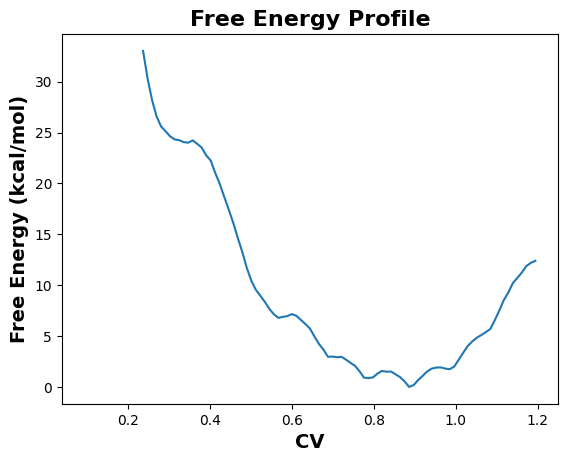

NoneIt seems that the WHAM analysis could not be performed successfully. Please check the parameters provided or let me know if you need assistance with something else.

> Finished chain.
It seems that the WHAM analysis could not be performed successfully. Please check the parameters provided or let me know if you need assistance with something else.


In [8]:
## Define class for description of inputs in structured tool 
class wham_analysis_Inputs(BaseModel):
    n_points: int = Field(description="Number of umbrella sampling points")
    cv_min: float = Field(description="Minimum value of the CV")
    cv_max: float = Field(description="Maximum value of the CV")
    k: float = Field(description="Force constant for the harmonic bias potential")
    T: float = Field(description="Temperature in K")


## Define function 
def wham_analysis(n_points,cv_min,cv_max,k,T):
    import numpy as np

    ## Define CV range
    values = np.linspace(cv_min, cv_max, n_points)

    ### Convert K in kJ/mol to kcal/mol
    k_kcal= k* 0.239006

    # Write the metafile
    with open('wham_metafile', 'w') as file:
        for i, value in enumerate(values):
            line = f"./production_runs/umbrella_{i}/dihedral_{i}.dat {round(values[i],2)} {k_kcal} \n"
            file.write(line)

    ## Write the wham_analysis.sh file
    with open('wham_analysis.sh', 'w') as file:
        print(f"""#!/bin/bash

# Usage: wham [P|Ppi|Pval] hist_min hist_max num_bins tol temperature numpad \
#        metadatafile freefile [num_MC_trials randSeed]
./wham/wham/wham {cv_min} {cv_max} 100 0.0001 {T} 1 wham_metafile wham_freefile > wham_output """,file=file)
        
    ## Create a soft link of the wham directory inside the current directory if it does not exist
    if not os.path.exists("wham"):
        os.system("ln -s /scratch365/omendibl/Molec_Mindset/DynaMate_V2/tutorials/4_enhanced_sampler/wham .")

    ## Run the wham_analysis.sh file
    os.system("bash wham_analysis.sh")

    ## plot the free energy profile
    free = np.loadtxt("wham_freefile")
    import matplotlib.pyplot as plt
    plt.plot(free[:,0], free[:,1])
    plt.xlabel("CV", fontsize=14, fontweight='bold')
    plt.ylabel("Free Energy (kcal/mol)", fontsize=14, fontweight='bold')
    plt.title("Free Energy Profile", fontsize=16, fontweight='bold')
    plt.savefig("free_energy_profile.png")
    plt.show()
    return
# ## Test the function 
# # defin einputs
# n_points = 10
# cv_min = 0.1
# cv_max = 1.2
# k = 4000
# T = 300
# atom_1 = 319
# atom_2 = 320

# os.chdir("tool_3")
# wham_analysis(n_points,cv_min,cv_max,k,T)
# os.chdir("..")

## Define Structured Tool
wham_analysis_tool = StructuredTool.from_function(
    func=wham_analysis, # Function to be used
    name="wham_analysis_tool", # Function to be used
    description="Perform WHAM analysis on umbrella sampling simulations using one collective variable.", # Description of the tool
    args_schema=wham_analysis_Inputs, # Schema of the inputs defined in class
    return_direct=False, # Return the output directly
    handle_error=True, # Handle errors
    # Use dictionary as input
    )


## Define LLM
# llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.0)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)

# Define list of tools the LLM is going to use 
tools = [wham_analysis_tool]

## Propomt for openai function
prompt = hub.pull("hwchase17/openai-functions-agent")
#print(prompt)

# Create OpenAI functions agent
agent = create_openai_functions_agent(llm=llm, tools=tools, prompt=prompt)

# ## Create Agent executor
agent_executor = AgentExecutor(agent=agent,tools=tools,verbose=True,handle_parsing_errors=True)

def wham_response(input_text:str):
    return agent_executor.invoke({"input": input_text})['output']

## Define test prompt
test_prompt_4 = "Perform WHAM analysis on umbrella sampling simulations using one collective variable. The number of umbrella sampling points is 10, the minimum value of the CV is 0.1, the maximum value of the CV is 1.2, the force constant for the harmonic bias potential is 4000, and the temperature is 300 K."

# Create and move to tool_1 directory
# os.makedirs("tool_3", exist_ok=True)
os.chdir("tool_3")
print(wham_response(test_prompt_4))
os.chdir("..")


### Tool 4: UmbSamp_analysis_tool

Tool to visualize the Sampled CV values in the umbrella simulations




> Entering new AgentExecutor chain...

Invoking: `UmbSamp_analysis_tool` with `{'path': 'production_runs', 'n_umbrellas': 10}`




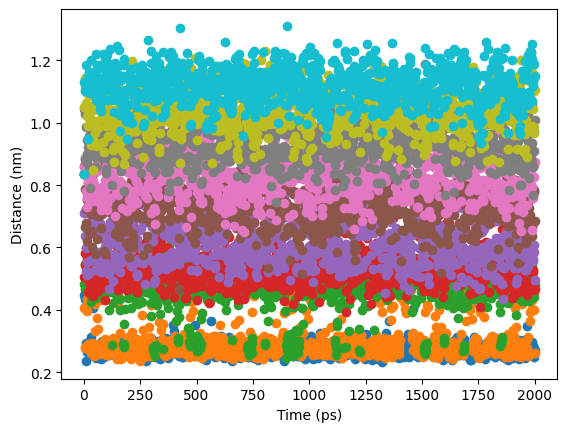

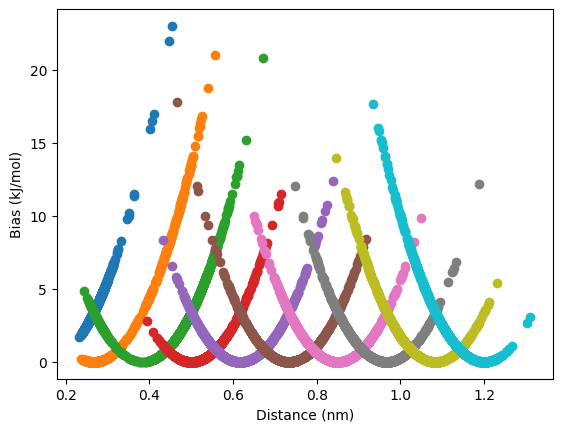

None


> Finished chain.
None


In [19]:
## Define class for description of inputs in structured tool 
class UmbSamp_analysis_Inputs(BaseModel):
    path: str = Field(description="Path to the umbrella production folders")
    n_umbrellas: int = Field(description="Number of umbrella sampling simulations")

## Define function
def UmbSamp_analysis(path, n_umbrellas):
    import plumed
    import matplotlib.pyplot as plt

    for i in range(n_umbrellas):
        data = plumed.read_as_pandas(f"{path}/umbrella_{i}/dihedral_{i}.dat")
        plt.scatter(data["time"], data["d1"], label=f"Umbrella {i}")
    plt.xlabel("Time (ps)")
    plt.ylabel("Distance (nm)")
    plt.savefig("distance_v_time.png")
    plt.show()

    for i in range(n_umbrellas):
        data = plumed.read_as_pandas(f"{path}/umbrella_{i}/dihedral_{i}.dat")
        plt.scatter( data["d1"][5:],data["bb.bias"][5:], label=f"Umbrella {i}")

    plt.xlabel("Distance (nm)")
    plt.ylabel("Bias (kJ/mol)")
    plt.savefig("bias_v_distance.png")
    plt.show()

    return

# path = 'tool_3/production_runs'
# n_umbrellas = 10
# UmbSamp_analysis(path, n_umbrellas)

## Define Structured Tool
UmbSamp_analysis_tool = StructuredTool.from_function(
    func=UmbSamp_analysis, # Function to be used
    name="UmbSamp_analysis_tool", # Function to be used
    description="Analyze umbrella sampling simulations using one collective variable.", # Description of the tool
    args_schema=UmbSamp_analysis_Inputs, # Schema of the inputs defined in class
    return_direct=True, # Return the output directly
    handle_error=False, # Handle errors
    # Use dictionary as input
    )


## Define LLM
# llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.0)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)

# Define list of tools the LLM is going to use 
tools = [UmbSamp_analysis_tool]

## Propomt for openai function
prompt = hub.pull("hwchase17/openai-functions-agent")
#print(prompt)

# Create OpenAI functions agent
agent = create_openai_functions_agent(llm=llm, tools=tools, prompt=prompt)

# ## Create Agent executor
agent_executor = AgentExecutor(agent=agent,tools=tools,verbose=True,handle_parsing_errors=True)

def UmbSamp_response(input_text:str):
    return agent_executor.invoke({"input": input_text})['output']

## Define test prompt
test_prompt_4 = "Analyze umbrella sampling simulations using one collective variable. The path to the umbrella production folders is 'production_runs' and the number of umbrella sampling simulations is 10."

# Create and move to tool_1 directory
# os.makedirs("tool_3", exist_ok=True)
os.chdir("tool_3")
print(UmbSamp_response(test_prompt_4))
os.chdir("..")

### Tool 5: MetaD_prep_tool 

Tool to generate PLUMED input files for Metadynamics simulations using a torsion angle CV. The tool assumes availability of previously generated data and input files for LAMMPS.





In [20]:
## Define class for description of inputs in structured tool 
class Prep_MetaD_Inputs(BaseModel):
    input_file: str = Field(description="Input file for LAMMPS")
    atoms_dihed_1: list = Field(description="Atoms for dihedral 1")
    atoms_dihed_2: list = Field(description="Atoms for dihedral 2")
    pace: int = Field(description="Pace for Gaussian deposition")
    height: float = Field(description="Initial height of Gaussian")
    bias_factor: int = Field(description="Bias factor")
    sigma: float = Field(description="Sigma value for Gaussian")
    T: float = Field(description="Temperature in K")
    


def prep_MetaD_inp(input_file, atoms_dihed_1, atoms_dihed_2, pace, height, bias_factor, sigma, T):
    import numpy as np

    ### write plumed input 
    with open("plumed_MetaD.dat","w") as f:
        print(f"""

# vim:ft=plumed
cv1: TORSION ATOMS={','.join(str(i) for i in atoms_dihed_1)}   
cv2: TORSION ATOMS={','.join(str(i) for i in atoms_dihed_2)}
                            

# Activate well-tempered metadynamics in phi
metad: METAD ARG=cv1,cv2 ...
   # Deposit a Gaussian every 500 time steps, with initial height
   # equal to 0.3 kJ/mol and bias factor equal to 5
   PACE={pace} HEIGHT={height} BIASFACTOR={bias_factor}
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run
   SIGMA={sigma},{sigma}
   TEMP={T}
   CALC_RCT
   # Gaussians will be written to file and also stored on grid
   FILE=HILLS GRID_MIN=-pi,-pi GRID_MAX=pi,pi GRID_BIN=100,100
...

PRINT ARG=* FILE=colvar.dat STRIDE=100 """,file=f)

    # Read the contents of the template file once
    with open(input_file, 'r') as file:
        template_lines = file.readlines()

    # Create a copy of the template lines for each file
    lines = template_lines[:]
    
    # Identify the first 'fix ' command and modify it to 'fix plumed'
    first_fix_index = None
    for index, line in enumerate(lines):
        if line.strip().startswith("fix "):
            first_fix_index = index
            break  # Stop at the first occurrence

    # Insert 'fix plumed' as the first 'fix' command
    if first_fix_index is not None:
        lines.insert(first_fix_index, f"fix umb all plumed plumedfile plumed_MetaD.dat outfile plumed.out\n")
    else:
        # If no 'fix' command is found, add 'fix plumed' at the end
        lines.append(f"No fix commands found\n")
    
    # Define the new filename
    new_filename = f"modified_input_MetaD.in"
    
    # Write the modified lines to the new file
    with open(new_filename, 'w') as new_file:
        new_file.writelines(lines)

    return
# input_file = "in.ADP_Example"
# atoms_dihed_1 = 5, 7, 9, 15
# atoms_dihed_2 = 7, 9, 15, 17
# pace = 100
# height = 1.0
# bias_factor = 4
# sigma = 0.3
# T = 300
# os.chdir("tool_5")
# prep_MetaD_inp(input_file, atoms_dihed_1, atoms_dihed_2, pace, height, bias_factor, sigma, T)
# os.chdir("..")

## Define Structured Tool
Prep_Metad_Inps_tool = StructuredTool.from_function(
    func=prep_MetaD_inp, # Function to be used
    name="prep_MetaD_inp_tool", # Function to be used
    description="Generate PLUMED input files for metadynamics simulations using dihedral angles as collective variables.", # Description of the tool
    args_schema=Prep_MetaD_Inputs, # Schema of the inputs defined in class
    return_direct=False, # Return the output directly
    handle_error=True, # Handle errors
    # Use dictionary as input
    )


## Define LLM
# llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.0)
llm = ChatOpenAI(model="gpt-4o", temperature=0.0)

# Define list of tools the LLM is going to use 
tools = [Prep_Metad_Inps_tool]

## Propomt for openai function
prompt = hub.pull("hwchase17/openai-functions-agent")
#print(prompt)

# Create OpenAI functions agent
agent = create_openai_functions_agent(llm=llm, tools=tools, prompt=prompt)

# ## Create Agent executor
agent_executor = AgentExecutor(agent=agent,tools=tools,verbose=True,handle_parsing_errors=True)

def Metad_gen_response(input_text:str):
    return agent_executor.invoke({"input": input_text})['output']

## Define test prompt 
test_prompt_1 = "Generate PLUMED input files for metadynamics simulations using dihedral angles as collective variables. \
    The input file for LAMMPS is 'in.ADP_Example', the atoms for dihedral 1 are 5, 7, 9, 15, the atoms for dihedral 2 are 7, 9, 15, 17, \
            the pace for Gaussian deposition is 100, the initial height of Gaussian is 1.0, the bias factor is 4, the sigma value for Gaussian is 0.3, \
                and the temperature is 300 K."

os.chdir("tool_5")
print(Metad_gen_response(test_prompt_1))
os.chdir("..")



> Entering new AgentExecutor chain...

Invoking: `prep_MetaD_inp_tool` with `{'input_file': 'in.ADP_Example', 'atoms_dihed_1': [5, 7, 9, 15], 'atoms_dihed_2': [7, 9, 15, 17], 'pace': 100, 'height': 1.0, 'bias_factor': 4, 'sigma': 0.3, 'T': 300}`


NoneThe PLUMED input files for the metadynamics simulation have been generated using the specified parameters. You can now use these files in your simulation setup. If you need further assistance or details, feel free to ask!

> Finished chain.
The PLUMED input files for the metadynamics simulation have been generated using the specified parameters. You can now use these files in your simulation setup. If you need further assistance or details, feel free to ask!


### Tool 6: Metad_analysis_tool 

Tool to analyze and plot data analyze data from Metadynamics simulation.



In [22]:
## Define class for description of inputs in structured tool 
import os
from dotenv import load_dotenv
import subprocess
import warnings
warnings.filterwarnings("ignore")
from langchain.pydantic_v1 import BaseModel, Field
from langchain.tools import BaseTool, StructuredTool, tool
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor,create_react_agent,create_openai_functions_agent # To load simple ReAct agent. Reason an act
from langchain import hub

# Define API key for OPenAI
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")

## Define class for description of inputs in structured tool
class MetaD_analysis_Inputs(BaseModel):
    path: str = Field(description="Path to the umbrella production folders")
    dim: int = Field(description="Dimension of the free energy surface (1 or 2)")
    cv: str = Field(description="Name of the collective variable to be analyzed")

## Define function
def MetaD_analysis(path,dim,cv="cv1"):
    import plumed
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import glob
    import natsort

    # Load data
    data = plumed.read_as_pandas(f"{path}")
    ## Plot CVs vs Time
    plt.scatter(data["time"], data["cv1"], label=f"CV1")
    plt.scatter(data["time"], data["cv2"], label=f"CV2")
    plt.xlabel("Time (ps)")
    plt.ylabel("Angle (radians)")
    plt.legend()
    #plt.savefig("angle_v_time.png")
    plt.show()

    ## PLot CV vs CV
    plt.scatter(data["cv1"], data["cv2"])
    plt.xlabel("CV1")
    plt.ylabel("CV2")
    #plt.savefig("cv1_v_cv2.png")
    plt.show()

    ## Run the sum_hills command to obtain the 2Dfree energy surface
    if dim == 2:
        os.system("rm bck.*")
        os.system("plumed sum_hills --hills HILLS --stride 1000 --mintozero")

        ## Load the 2D free energy surface and plot 
        dim2_data = plumed.read_as_pandas(natsort.natsorted(glob.glob("fes_*.dat"))[-1])
        # Load the FES data
        fes = np.loadtxt(natsort.natsorted(glob.glob("fes_*.dat"))[-1])

        # Extract the phi, psi, and FES values
        phi = fes[:, 0]
        psi = fes[:, 1]
        fes_values = fes[:, 2]

        # Reshape the FES values into a grid
        nbins_phi = len(np.unique(phi))
        nbins_psi = len(np.unique(psi))
        fes_grid = fes_values.reshape(nbins_phi, nbins_psi)

        # Create meshgrid for phi and psi
        phi_grid, psi_grid = np.meshgrid(np.unique(phi), np.unique(psi))

        # Convert the energy to kcal/mol
        fes_grid_kcal = fes_grid * 0.239

        # Set the size and background color of the plot
        plt.figure(figsize=(8, 6))
        plt.rcParams['axes.facecolor'] = 'white'

        # Plot the FES as a surface or grid with modified color scale
        plt.pcolormesh(phi_grid, psi_grid, fes_grid_kcal, cmap='plasma', shading='nearest', vmin=0, vmax=20)
        plt.colorbar(label="Free Energy (kcal/mol)", ) #ticks=np.arange(0, 21, 5)
        plt.xlabel("phi (rad)", fontsize=14)
        plt.ylabel("psi (rad)", fontsize=14)
        #plt.title("OnlyMins 1000 Frames SPC",fontsize=18,fontweight='bold')
        # Add contour lines every 2.5 kcal/mol
        contour_levels = np.arange(0, 20, 0.5)
        plt.contourf(phi_grid, psi_grid, fes_grid_kcal, levels=contour_levels,cmap='plasma')
        plt.show()

    elif dim == 1:
        os.system(f"plumed sum_hills --hills HILLS --stride 1000 --mintozero --kt 2.49 --idw {cv}")

        ## Load the 1D free energy surface and plot 
        reweight_data = plumed.read_as_pandas(natsort.natsorted(glob.glob("fes_*.dat"))[-1])
        plt.figure(figsize=(8, 6), dpi=150,facecolor='w', edgecolor='k')
        plt.plot(reweight_data["{cv}"], reweight_data["projection"]*0.239006, label=f"Reweighted {cv}", color='black',linewidth=2)
        plt.xlabel("$\phi$ [radians]", fontsize=18, fontweight='bold')
        plt.ylabel("Free energy [Kcal/mol]", fontsize=18, fontweight='bold')
        plt.tick_params(axis='both', which='major', labelsize=16)
        plt.xlim(-180, 180)
        # plt.legend()
        plt.show()
    return

# # test function
# path = './'
# MetaD_analysis(path,2,cv="cv1")

## Define Structured Tool
MetaD_analysis_tool = StructuredTool.from_function(
    func=MetaD_analysis, # Function to be used
    name="MetaD_analysis_tool", # Function to be used
    description="Analyze the output of a metadynamics simulation in one or two dimensions. The inputs are the path to the metadynamics production run, the dimension of the free energy surface (1 or 2), and the name of the collective variable to be analyzed.", # Description of the tool
    args_schema=MetaD_analysis_Inputs, # Schema of the inputs defined in class
    return_direct=True, # Return the output directly
    handle_error=False, # Handle errors
    # Use dictionary as input
    )


## Define LLM
# llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.0)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)

# Define list of tools the LLM is going to use 
tools = [MetaD_analysis_tool]

## Propomt for openai function
prompt = hub.pull("hwchase17/openai-functions-agent")
#print(prompt)

# Create OpenAI functions agent
agent = create_openai_functions_agent(llm=llm, tools=tools, prompt=prompt)

# ## Create Agent executor
agent_executor = AgentExecutor(agent=agent,tools=tools,verbose=True,handle_parsing_errors=True)

def MetaD_Analysis_response(input_text:str):
    return agent_executor.invoke({"input": input_text})['output']

## Define test prompt 
test_prompt_1 = "Analyze the output of a metadynamics simulation in two dimensions. The path to the metadynamics production run is './'. The dimension of the free energy surface is 2 and the name of the collective variable to be analyzed is 'cv1'."

# Create and move to tool_1 directory
# os.chdir("tool_5")
print(MetaD_Analysis_response(test_prompt_1))
# os.chdir("..")



> Entering new AgentExecutor chain...

Invoking: `MetaD_analysis_tool` with `{'path': './', 'dim': 2, 'cv': 'cv1'}`




IsADirectoryError: [Errno 21] Is a directory: './'

## Note: 

This tool has some errors when used in the notebook but runs properly from the python script 